# Recommendation of tariffs

We have data on the behavior of customers who have already switched to these tariffs. We need to build a model for the classification task that will select the appropriate tariff. There is no need for data preprocessing - we have already done it.

Let's build a model with the largest *accuracy* value.

## Let's open and examine the file

In [1]:
import pandas as pd
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/datasets/users_behavior.csv')
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0
5,58.0,344.56,21.0,15823.37,0
6,57.0,431.64,20.0,3738.90,1
7,15.0,132.40,6.0,21911.60,0
8,7.0,43.39,3.0,2538.67,1
9,90.0,665.41,38.0,17358.61,0


All data has been successfully downloaded. All column types are converted to the correct data type, there are also no gaps, which is good news, so we’ll skip the preprocessing and go straight to breaking down the samples.

## Let's split the data into samples

Since there is no test sample, we will divide our dataset in a ratio of 3:1:1, where 3 is the training sample, 1 is the validation sample and 1 is the test sample. To ensure fairness of the breakdown, we will specify the stratify parameter.

In [3]:
features = df.drop('is_ultra', axis=1)
target = df['is_ultra']

features_for_split, features_test, target_for_split, target_test = train_test_split(features, target, test_size=0.2,
                                                                                    random_state=12345, stratify=target)

features_train, features_valid, target_train, target_valid = train_test_split(features_for_split, target_for_split,
                                                                              test_size=0.25, random_state=12345, stratify=target_for_split)

In [4]:
display(features_test)
display(target_test)

,calls,minutes,messages,mb_used
2424,56.0,364.36,0.0,14129.94
2118,76.0,430.70,34.0,25138.49
2034,108.0,812.04,4.0,24490.28
2286,67.0,460.76,27.0,16626.26
1364,69.0,515.52,34.0,21231.90
...,...,...,...,...
2295,10.0,61.30,0.0,958.19
2327,58.0,370.03,29.0,33526.69
1983,44.0,293.54,51.0,11816.92
2315,48.0,341.65,0.0,19000.02


2424    0
2118    0
2034    1
2286    0
1364    0
       ..
2295    0
2327    1
1983    0
2315    0
873     0
Name: is_ultra, Length: 643, dtype: int64

In [5]:
display(features_train)
display(features_valid)
display(target_train)
display(target_valid)

,calls,minutes,messages,mb_used
1659,27.0,170.58,23.0,21798.61
2176,75.0,489.47,7.0,20478.94
108,47.0,300.12,123.0,31244.61
426,36.0,198.96,32.0,21596.86
1892,102.0,740.28,19.0,17864.12
...,...,...,...,...
2298,64.0,475.68,20.0,8540.27
397,80.0,547.01,54.0,21265.57
1439,38.0,275.74,16.0,7122.54
3151,84.0,622.60,32.0,16318.74


,calls,minutes,messages,mb_used
580,43.0,321.63,42.0,25599.87
2272,93.0,658.89,38.0,17655.47
1415,82.0,507.89,88.0,17543.37
1356,43.0,256.90,1.0,10450.48
1910,111.0,728.20,37.0,14135.23
...,...,...,...,...
3133,56.0,385.68,28.0,18148.98
2268,10.0,78.67,8.0,4986.91
49,58.0,474.92,11.0,17858.59
1980,47.0,367.09,42.0,22329.28


1659    0
2176    1
108     1
426     0
1892    0
       ..
2298    0
397     0
1439    0
3151    0
607     1
Name: is_ultra, Length: 1928, dtype: int64

580     1
2272    1
1415    1
1356    0
1910    0
       ..
3133    0
2268    0
49      0
1980    0
2867    0
Name: is_ultra, Length: 643, dtype: int64

In [6]:
display(features_train.shape)
display(features_valid.shape)
display(features_test.shape)
display(target_train.shape)
display(target_valid.shape)
display(target_test.shape)

(1928, 4)

(643, 4)

(643, 4)

(1928,)

(643,)

(643,)

## Explore models

Let's create a dictionary to record the best models and their accuracy on the validation set.

In [7]:
dict_model = {}

Since the tree is highly prone to overfitting, we will set a small depth of 2-5.

In [8]:
best_model_tree = None
best_result_tree = 0
arr_acc_train = list()
arr_acc_valid = list()

for depth in range(2, 4):
    model_tree = DecisionTreeClassifier(max_depth=depth, random_state=12345)
    model_tree.fit(features_train, target_train)
    arr_acc_train.append(model_tree.score(features_train, target_train))
    predictions = model_tree.predict(features_valid)
    result = accuracy_score(target_valid, predictions)
    arr_acc_valid.append(result)
    if result > best_result_tree:
        best_result_tree = result
        best_model_tree = model_tree
dict_model[best_model_tree] = best_result_tree

print("Best accuracy:", best_result_tree)

Best accuracy: 0.8040435458786936


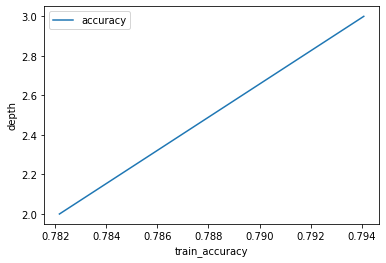

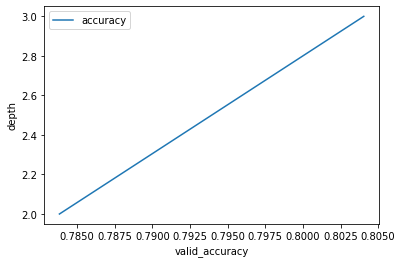

In [9]:
df_plot = pd.DataFrame({'valid_accuracy': arr_acc_valid, 'train_accuracy': arr_acc_train, 'depth': range(2, 4)})

df_plot.plot(x='train_accuracy', y='depth')
plt.ylabel('depth')
plt.legend(['accuracy'])
plt.show()
df_plot.plot(x='valid_accuracy', y='depth')
plt.ylabel('depth')
plt.legend(['accuracy'])
plt.show()

Accuracy of 0.76 for one tree is impressive, let's see how others perform.

We will also display our model in the form of a clear graph.

Index(['calls', 'minutes', 'messages', 'mb_used'], dtype='object')


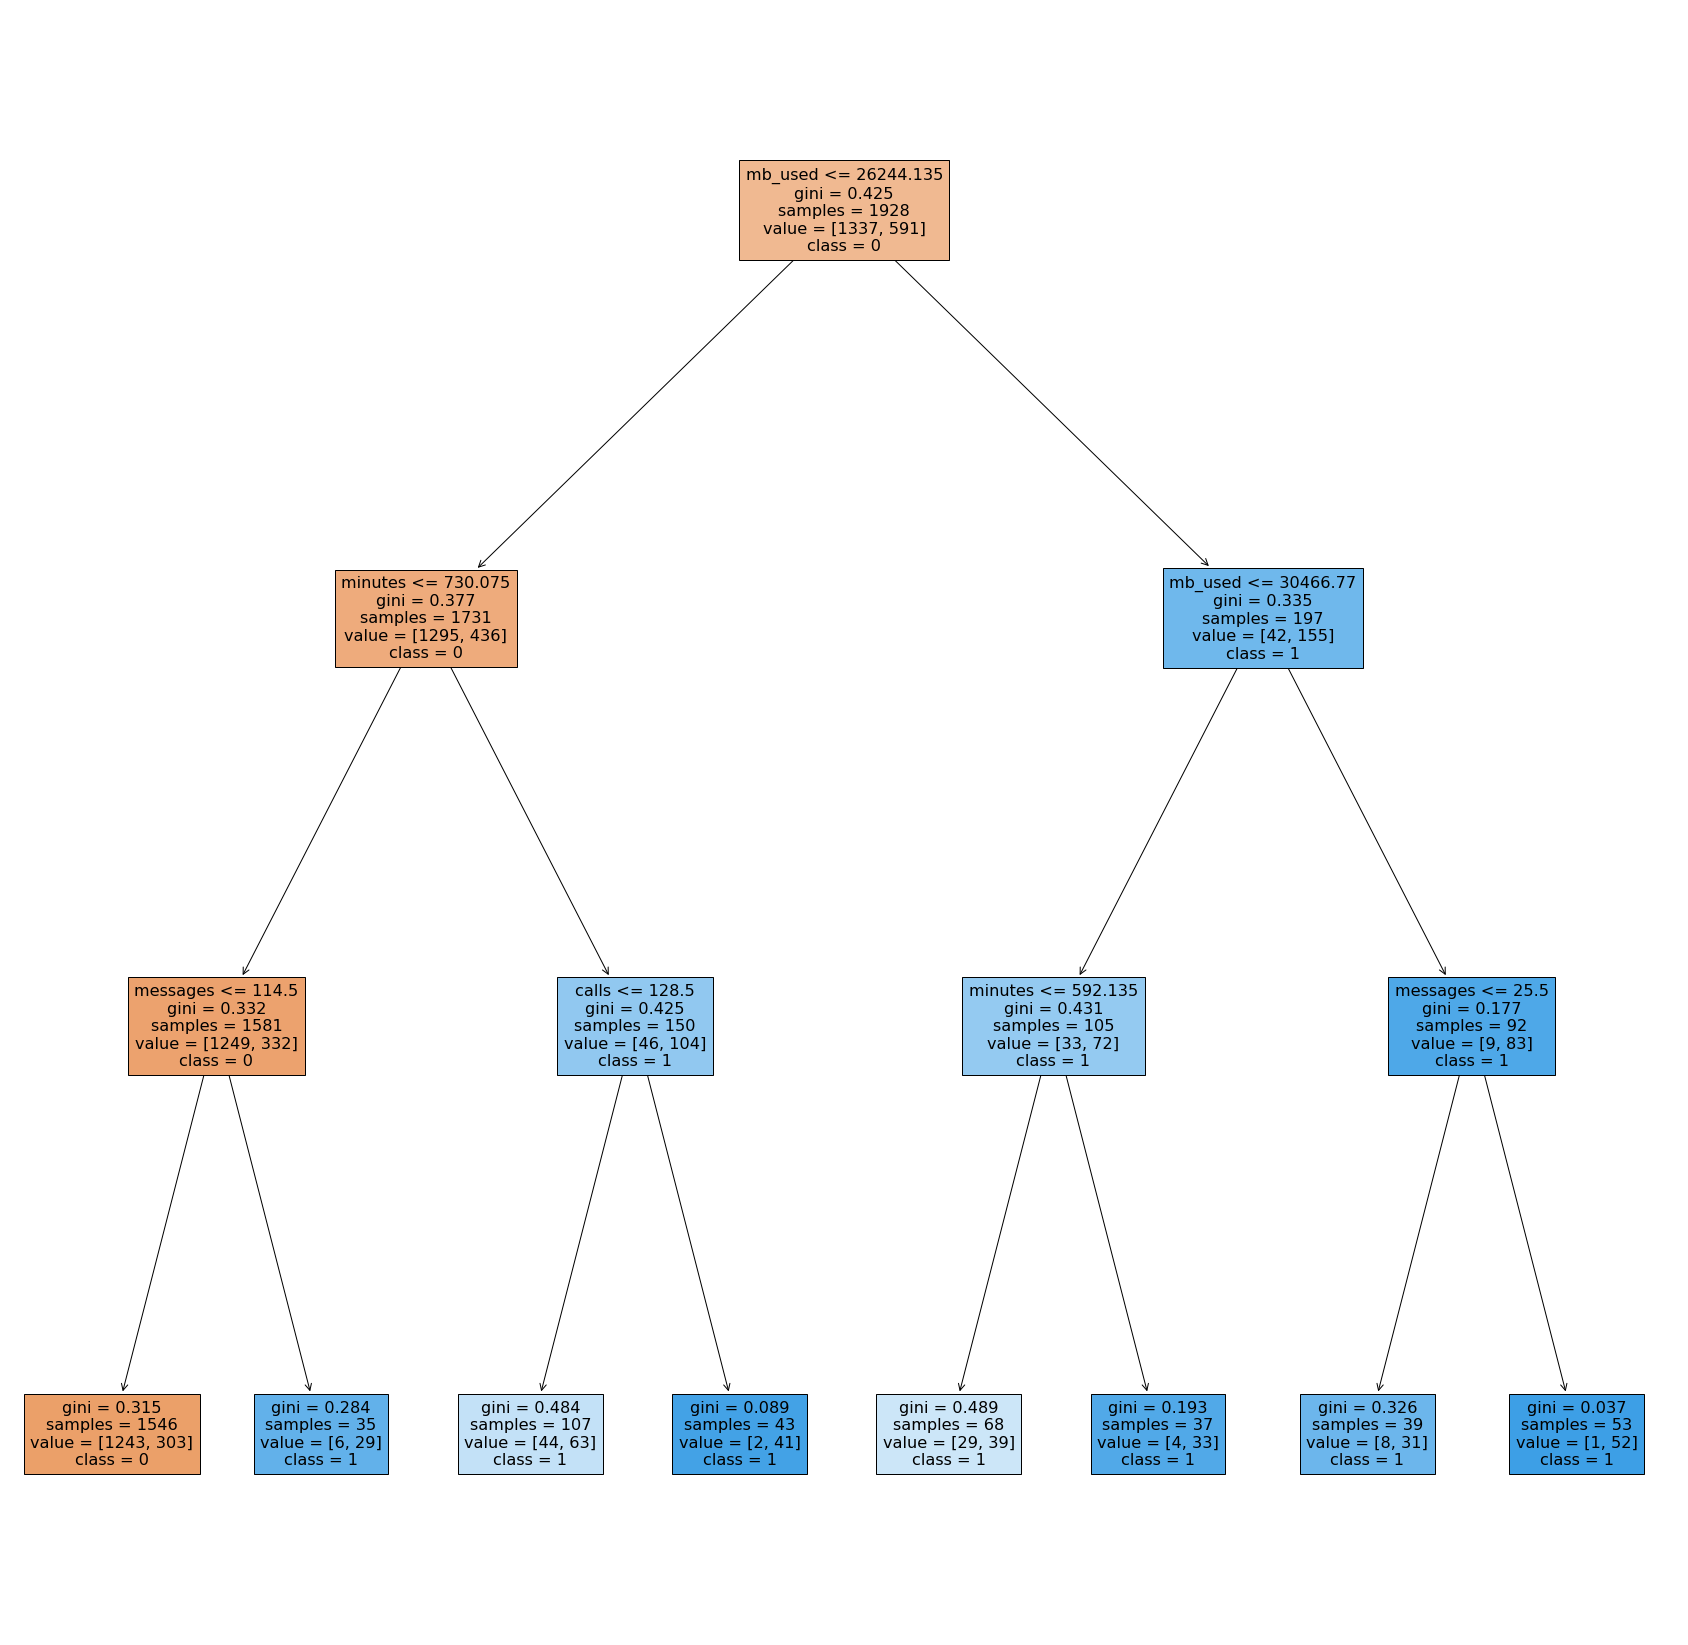

In [10]:
plt.figure(figsize=(30, 30))
print(features.columns)
_ = tree.plot_tree(best_model_tree,
                   feature_names=features.columns,
                   class_names=['0', '1'],
                   filled=True)
plt.show()

There is already a forest here, but it is also prone to overfitting, although not as much as a separate tree, so we will indicate a larger depth here: 3-9, and the number of trees 3-7.

In [11]:
best_model_forest = None
best_result_forest = 0
arr_acc_train = list()
arr_acc_valid = list()
for trees in range(3, 8):
    for depth in range(3, 10):
        model_forest = RandomForestClassifier(random_state=12345, n_estimators=trees, max_depth=depth)
        model_forest.fit(features_train, target_train)
        arr_acc_train.append(model_forest.score(features_train, target_train))
        predictions = model_forest.predict(features_valid)
        result = accuracy_score(target_valid, predictions)
        arr_acc_valid.append(result)
        if result > best_result_tree:
            best_result_forest = result
            best_model_forest = model_forest
dict_model[best_model_forest] = best_result_forest

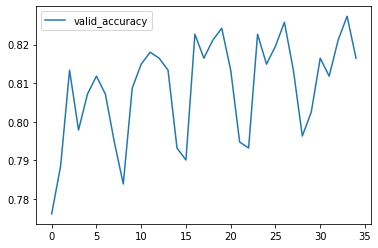

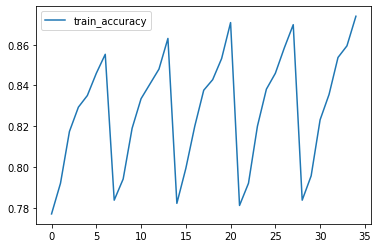

In [12]:
df_plot = pd.DataFrame({'valid_accuracy': arr_acc_valid, 'train_accuracy': arr_acc_train})

plt.plot(df_plot['valid_accuracy']);
plt.legend(['valid_accuracy'])
plt.show()


plt.plot(df_plot['train_accuracy']);
plt.legend(['train_accuracy'])
plt.show()

Here you can play around with the number of iterations, but after 100 the accuracy does not change.

In [13]:
best_model_logic = None
best_result_logic = 0

model_logic = LogisticRegression(random_state=12345, solver='lbfgs', max_iter=100)
model_logic.fit(features_train, target_train)
arr_acc_train.append(model_logic.score(features_train, target_train))
result = model_logic.score(features_valid, target_valid)
arr_acc_valid.append(result)
dict_model[model_logic] = result

In [14]:
dict_model

{DecisionTreeClassifier(max_depth=3, random_state=12345): 0.8040435458786936,
 RandomForestClassifier(max_depth=9, n_estimators=7, random_state=12345): 0.8164852255054432,
 LogisticRegression(random_state=12345): 0.7558320373250389}

Thus, the highest accuracy at the stage of the validation sample is shown by a random forest, then by a tree, and only then by logical regression. The expectations were different - 3rd and 2nd places were swapped.

## Let's check the model on a test sample

Although there is a favorite - Random Forest, it would still be nice to go through all the models in case something changes.

In [15]:
best_model = None
best_result = 0
for models, results in dict_model.items():
    if models.score(features_test, target_test) > best_result:
        best_result = models.score(features_test, target_test)
        best_model = models
        print(models, models.score(features_test, target_test))

print("Best model:", best_model)
print("This model accuracy:", best_result)

DecisionTreeClassifier(max_depth=3, random_state=12345) 0.7993779160186625
RandomForestClassifier(max_depth=9, n_estimators=7, random_state=12345) 0.8118195956454122
Best model: RandomForestClassifier(max_depth=9, n_estimators=7, random_state=12345)
This model accuracy: 0.8118195956454122


An accuracy of 0.81 is quite good for such a small adjustment of the model parameters.

Now, after our models are trained, all are checked on the test set, and the validation set has done its job, we will combine the training and validation sets, and we will train the models with our selected hyperparameters on this increased sample.

In [16]:
dict_model

{DecisionTreeClassifier(max_depth=3, random_state=12345): 0.8040435458786936,
 RandomForestClassifier(max_depth=9, n_estimators=7, random_state=12345): 0.8164852255054432,
 LogisticRegression(random_state=12345): 0.7558320373250389}

Let's create a new dictionary where we will record new trained models.

In [17]:
new_dict_model = {}

In [18]:
features_full_train = pd.concat([features_train, features_valid])
target_full_train = pd.concat([target_train, target_valid])

In [19]:
model_tree = DecisionTreeClassifier(max_depth=3, random_state=12345)
model_tree.fit(features_full_train, target_full_train)
new_dict_model[model_tree] = model_tree.score(features_test, target_test)
print(model_tree.score(features_test, target_test))

0.7620528771384136


In [20]:
model_forest = RandomForestClassifier(max_depth=9, random_state=12345, n_estimators=7)
model_forest.fit(features_full_train, target_full_train)
new_dict_model[model_forest] = model_forest.score(features_test, target_test)

print(model_forest.score(features_test, target_test))

0.8133748055987559


In [21]:
model_logistic = LogisticRegression(random_state=12345, solver='lbfgs', max_iter=100)
model_logistic.fit(features_full_train, target_full_train)
new_dict_model[model_logistic] = model_logistic.score(features_test, target_test)

print(model_logistic.score(features_test, target_test))

0.7091757387247278


In [22]:
new_dict_model

{DecisionTreeClassifier(max_depth=3, random_state=12345): 0.7620528771384136,
 RandomForestClassifier(max_depth=9, n_estimators=7, random_state=12345): 0.8133748055987559,
 LogisticRegression(random_state=12345): 0.7091757387247278}

In [23]:
print("Previous Decision Tree test accuracy: 0.7993779160186625")
print("Previous Random Forest test accuracy: 0.8118195956454122")
print("Previous Logistic Regression test accuracy: 0.7371695178849145")


Previous Decision Tree test accuracy: 0.7993779160186625
Previous Random Forest test accuracy: 0.8118195956454122
Previous Logistic Regression test accuracy: 0.7371695178849145


The results changed: for all models except Les, the accuracy fell, but for Les it increased quite a bit.

Let's check the models for adequacy

In [24]:
print(len(df))
print(len(target_test))

dummy_prediction = pd.Series([0] * len(target_test))
dummy_accuracy = accuracy_score(target_test, dummy_prediction)
dummy_accuracy

3214
643


0.6936236391912908

After checking for adequacy, the “stupid” model produced an accuracy of 0.69! This accuracy is of course lower than our favorite - 0.81, but it is not far off, there is something to work on and try to improve our model.

## Conclusion

The work done included loading and studying the data, given the lack of a test sample, it was necessary to correctly split the data for effective training of models. The following were trained: Tree, Random Forest, Logic Regression with a variety of hyperparameters, ranging from the number of iterations to the depth of the tree. Graphs were constructed showing the change in the accuracy of the models depending on the hyperparameters, and a visual diagram was constructed for the tree. The results at the validation stage were surprising - logical regression showed the worst result and confirmed it on the test set, but random forest turned out to be better in everything, showing the best result - 0.81 accuracy! After combining the training and validation sets, the model accuracy results changed, the Forest became more accurate. Our models were also tested for adequacy; they passed this test, because the accuracy of the “stupid” model was 0.69